In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from data.loader import fetch_prices
from strategy.walk_forward import run_parameter_grid
from strategy.portfolio import (
    build_equal_weight_portfolio,
    compute_train_stats,
    build_weighted_portfolio,
    portfolio_stats,
)

## Can We Know When to Be Defensive?

Notebook 09 showed that risk parity outperforms equal weight in specific years: 2020 (COVID), 2022 (Fed rate hikes), 2023 (regional banking stress). This was not random: risk parity is structurally more defensive, so it outperforms when markets are turbulent and spreads whipsaw. In calm years, both methods produce similar results.

That pattern raises an obvious question: **can we detect the turbulent years in advance, before they damage the portfolio?**

If we could, we would allocate to risk parity in turbulent regimes to get the best of both methods. The portfolio would be defensive when it needs to be and fully allocated when conditions are favorable.

The VIX index is the most direct measure of market fear available in real time. It represents the implied volatility of S&P 500 options, reflecting how much the options market is pricing in uncertainty over the next 30 days. When the market is nervous, VIX rises. During COVID (March 2020), VIX hit 80. During the 2022 rate-hike selloff, it sustained above 25 for most of the year. In calm periods, it sits below 15.

The hypothesis: **when VIX is elevated (above 20), use risk parity; when VIX is calm (below 20), use equal weight.** The threshold is applied with a one-day lag: we use yesterday's VIX to decide today's allocation, which is what a live strategy would do.

The honest test: does this regime switching actually improve the portfolio, or does the lagged signal cause enough whipsaw that the gains from switching cancel out?

In [2]:
PROFITABLE_PAIRS = [('KO','PEP'), ('NUE','STLD'), ('V','MA'), ('GS','MS'), ('HD','LOW')]
START         = '2010-01-01'
END           = '2024-12-31'
TRAIN_YEARS   = 2
TEST_YEARS    = 1
COST_BPS      = 5.0
ENTRY_ZS      = [1.5, 2.0, 2.5]
EXIT_ZS       = [0.0, 0.5]
VIX_THRESHOLD = 20.0   # standard: < 20 = calm, > 20 = elevated

In [3]:
tickers = [t for pair in PROFITABLE_PAIRS for t in pair]
prices  = fetch_prices(tickers, START, END)

all_grids = {}
for t1, t2 in PROFITABLE_PAIRS:
    print(f"Running grid: {t1}/{t2}")
    all_grids[(t1, t2)] = run_parameter_grid(
        prices[[t1, t2]], t1, t2,
        entry_zs=ENTRY_ZS, exit_zs=EXIT_ZS,
        train_years=TRAIN_YEARS, test_years=TEST_YEARS,
        cost_bps=COST_BPS,
    )

best_configs = {}
best_wfs     = {}
for pair, grid in all_grids.items():
    best_key           = max(grid, key=lambda k: grid[k]['static_stats']['sharpe_ratio'])
    best_configs[pair] = best_key
    best_wfs[pair]     = grid[best_key]

print("\nPortfolio baseline:")
train_stats = compute_train_stats(prices, best_wfs, best_configs, cost_bps=COST_BPS)
ew_daily  = build_equal_weight_portfolio(best_wfs)
rp_daily, _ = build_weighted_portfolio(best_wfs, train_stats)
ew_stats  = portfolio_stats(ew_daily)
rp_stats  = portfolio_stats(rp_daily)
print(f"  Equal Weight: SR={ew_stats['sharpe_ratio']:.2f}  MaxDD={ew_stats['max_drawdown']:.1%}")
print(f"  Risk Parity:  SR={rp_stats['sharpe_ratio']:.2f}  MaxDD={rp_stats['max_drawdown']:.1%}")

Running grid: KO/PEP


Running grid: NUE/STLD


Running grid: V/MA


Running grid: GS/MS


Running grid: HD/LOW



Portfolio baseline:


  Equal Weight: SR=0.75  MaxDD=-9.6%
  Risk Parity:  SR=0.77  MaxDD=-8.7%


## 1. The VIX as a Regime Signal

Before building the regime portfolio, it helps to understand what the VIX looks like over the test period and how often we would be in the "high-vol" regime.

In [4]:
# Fetch VIX — yfinance ticker ^VIX
vix_raw = fetch_prices(["^VIX"], START, END)
vix     = vix_raw["^VIX"].dropna()

# Align to portfolio trading dates (some VIX dates may differ slightly)
vix_aligned = vix.reindex(ew_daily.index, method='ffill')

# Regime signal: lagged 1 day to avoid lookahead
vix_lag  = vix_aligned.shift(1)
high_vol = vix_lag > VIX_THRESHOLD

pct_high = high_vol.mean()
print(f"VIX statistics over test period ({ew_daily.index[0].date()} to {ew_daily.index[-1].date()}):")
print(f"  Mean VIX:           {vix_aligned.mean():.1f}")
print(f"  Median VIX:         {vix_aligned.median():.1f}")
print(f"  Max VIX:            {vix_aligned.max():.1f}")
print(f"  Days above {VIX_THRESHOLD:.0f}:      {high_vol.sum()} ({pct_high:.1%} of trading days)")
print(f"  Days below {VIX_THRESHOLD:.0f}:      {(~high_vol).sum()} ({1-pct_high:.1%} of trading days)")

VIX statistics over test period (2012-01-06 to 2024-01-04):
  Mean VIX:           17.8
  Median VIX:         16.0
  Max VIX:            82.7
  Days above 20:      790 (26.3% of trading days)
  Days below 20:      2217 (73.7% of trading days)


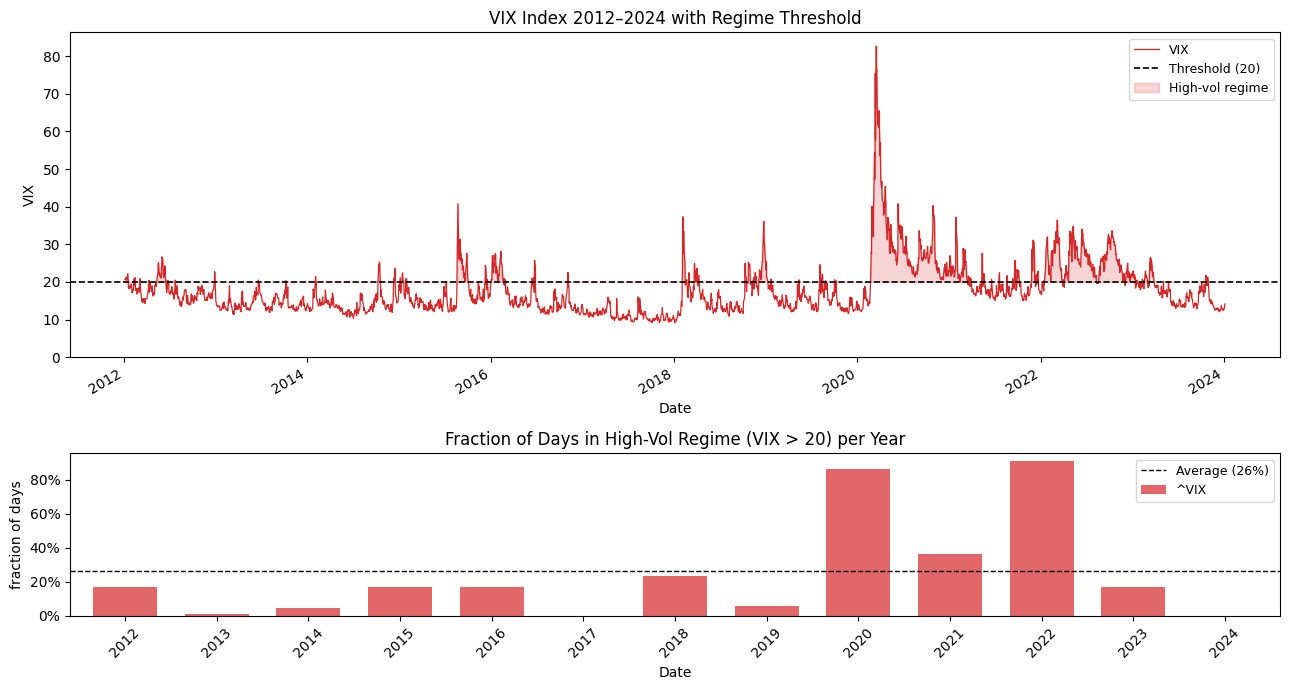

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7),
                         gridspec_kw={'height_ratios': [2, 1]})

# --- Top panel: VIX time series ---
vix_aligned.plot(ax=axes[0], color='#d62728', linewidth=0.9, label='VIX')
axes[0].axhline(VIX_THRESHOLD, color='k', linewidth=1.2, linestyle='--',
                label=f'Threshold ({VIX_THRESHOLD:.0f})')
axes[0].fill_between(
    vix_aligned.index,
    VIX_THRESHOLD,
    np.where(vix_aligned.values > VIX_THRESHOLD, vix_aligned.values, VIX_THRESHOLD),
    alpha=0.2, color='#d62728', label='High-vol regime',
)
axes[0].set_title('VIX Index 2012–2024 with Regime Threshold')
axes[0].set_ylabel('VIX')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, None)

# --- Bottom panel: fraction per year (bar chart — separate x-axis, no sharex) ---
high_vol_annual = high_vol.groupby(high_vol.index.year).mean()
high_vol_annual.plot(kind='bar', ax=axes[1], color='#d62728', alpha=0.7, width=0.7)
axes[1].axhline(pct_high, color='k', linewidth=1, linestyle='--',
                label=f'Average ({pct_high:.0%})')
axes[1].set_title('Fraction of Days in High-Vol Regime (VIX > 20) per Year')
axes[1].set_ylabel('fraction of days')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

> **Observations: VIX Regime Signal**
>
> Over the 2012–2024 test period, VIX exceeds 20 on 26.3% of trading days (790 out of 3,007). The high-vol regime is not rare, but it is also not the dominant state: markets spend nearly three-quarters of the time below 20. Mean VIX is 17.8, with a median of 16.0, which means the distribution is right-skewed, driven by a few high-stress periods rather than persistently elevated volatility.
>
> The per-year breakdown is striking. 2017 has exactly 0% of days above 20, and 2019 is nearly as calm at 6%. At the other extreme, 2020 (86%) and 2022 (91%) spent almost the entire year in the high-vol regime. The regime signal is not evenly distributed: it is concentrated in a handful of exceptional years.

## 2. Building the Regime-Aware Portfolio

The construction is straightforward: on each day, check yesterday's VIX. If VIX > 20, use the risk parity return for that day. If VIX ≤ 20, use the equal-weight return. No refitting, no parameter estimation; just selecting between two pre-computed daily PnL series based on the regime signal.

This is clean. The risk parity weights are derived from training data only (no lookahead). The VIX is lagged one day (no lookahead). The EW baseline has no parameters at all. The only design choice is the threshold of 20, which we fixed *before* looking at the results.

In [6]:
# Regime portfolio: use RP on high-vol days, EW on calm days
# vix_lag is already shifted 1 day — no additional lookahead
regime_daily = pd.Series(
    np.where(high_vol, rp_daily, ew_daily),
    index=ew_daily.index,
    name="regime",
)
regime_stats = portfolio_stats(regime_daily)

print(f"{'Method':<22} {'Sharpe':>8} {'Total Return':>13} {'Max Drawdown':>13}")
print("-" * 58)
for name, stats in [
    ('Equal Weight',  ew_stats),
    ('Risk Parity',   rp_stats),
    ('Regime-Aware',  regime_stats),
]:
    print(
        f"{name:<22}"
        f" {stats['sharpe_ratio']:>8.2f}"
        f" {stats['total_return']:>12.1%}"
        f" {stats['max_drawdown']:>13.1%}"
    )

Method                   Sharpe  Total Return  Max Drawdown
----------------------------------------------------------
Equal Weight               0.75        39.9%         -9.6%
Risk Parity                0.77        41.0%         -8.7%
Regime-Aware               0.73        40.4%         -9.0%


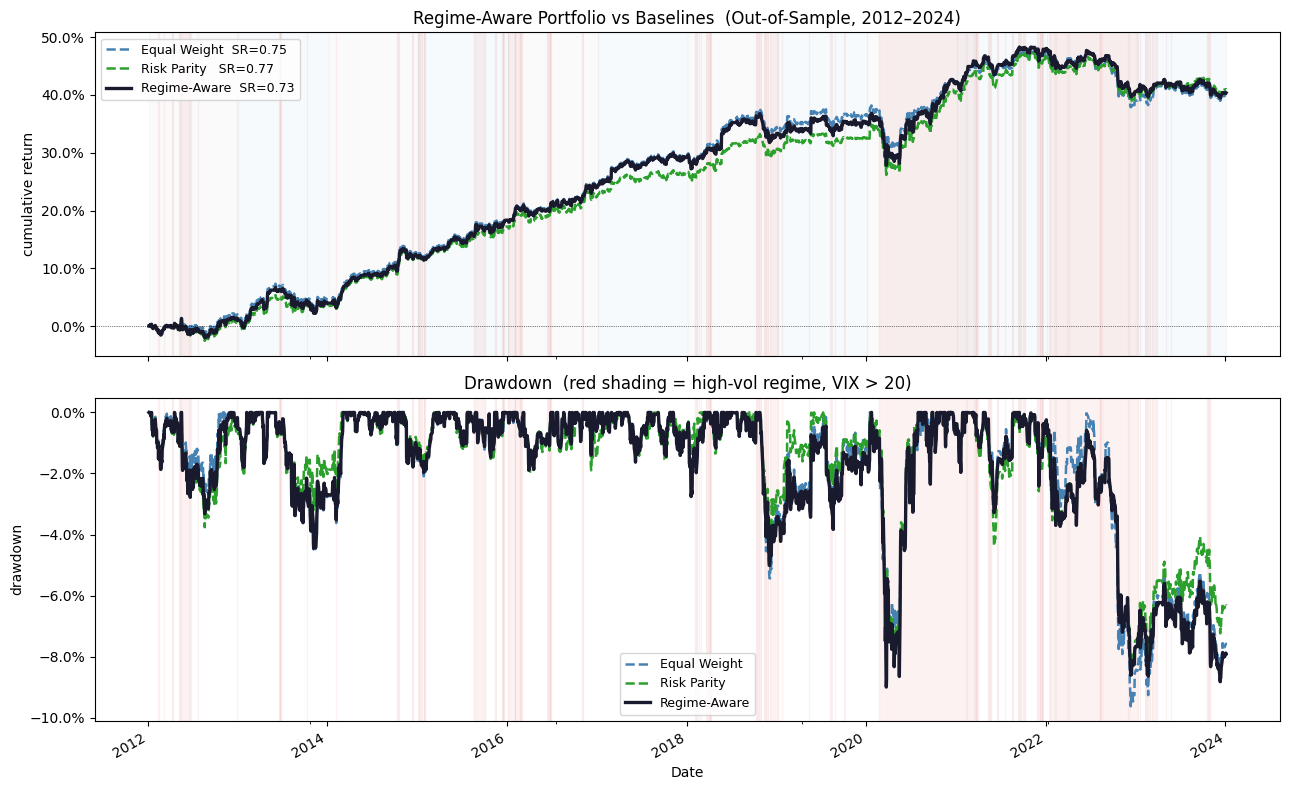

In [7]:
ew_eq     = ew_daily.cumsum()
rp_eq     = rp_daily.cumsum()
reg_eq    = regime_daily.cumsum()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ref_wf = best_wfs[PROFITABLE_PAIRS[0]]

# Shade high-vol regime periods
for i, w in enumerate(ref_wf['windows']):
    axes[0].axvspan(w['test_start'], w['test_end'],
                    alpha=0.04, color='grey' if i % 2 == 0 else 'steelblue')

# Shade high-vol regime in red (for regime context)
high_vol_plot = vix_aligned.reindex(ew_eq.index) > VIX_THRESHOLD
high_vol_changes = high_vol_plot.astype(int).diff().fillna(0)
start = None
for date, val in high_vol_changes.items():
    if val == 1:
        start = date
    elif val == -1 and start is not None:
        for ax in axes:
            ax.axvspan(start, date, alpha=0.06, color='#d62728', zorder=0)
        start = None

ew_eq.plot(ax=axes[0], color='steelblue', linewidth=1.8, linestyle='--',
           label=f'Equal Weight  SR={ew_stats["sharpe_ratio"]:.2f}')
rp_eq.plot(ax=axes[0], color='#2ca02c', linewidth=1.8, linestyle='--',
           label=f'Risk Parity   SR={rp_stats["sharpe_ratio"]:.2f}')
reg_eq.plot(ax=axes[0], color='#1a1a2e', linewidth=2.4,
            label=f'Regime-Aware  SR={regime_stats["sharpe_ratio"]:.2f}')

axes[0].axhline(0, color='k', linewidth=0.5, linestyle=':')
axes[0].set_title('Regime-Aware Portfolio vs Baselines  (Out-of-Sample, 2012–2024)')
axes[0].set_ylabel('cumulative return')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
axes[0].legend(fontsize=9)

ew_dd  = ew_eq  - ew_eq.cummax()
rp_dd  = rp_eq  - rp_eq.cummax()
reg_dd = reg_eq - reg_eq.cummax()
ew_dd.plot(ax=axes[1], color='steelblue', linewidth=1.8, linestyle='--', label='Equal Weight')
rp_dd.plot(ax=axes[1], color='#2ca02c', linewidth=1.8, linestyle='--', label='Risk Parity')
reg_dd.plot(ax=axes[1], color='#1a1a2e', linewidth=2.4, label='Regime-Aware')

axes[1].set_title('Drawdown  (red shading = high-vol regime, VIX > 20)')
axes[1].set_ylabel('drawdown')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
ew_ann  = ew_daily.groupby(ew_daily.index.year).sum()
rp_ann  = rp_daily.groupby(rp_daily.index.year).sum()
reg_ann = regime_daily.groupby(regime_daily.index.year).sum()

# % of days each year that were high-vol
hv_pct = high_vol.groupby(high_vol.index.year).mean()

print(f"{'Year':<6} {'VIX>20':>7} {'EW':>9} {'RP':>9} {'Regime':>9} {'Winner':>8}")
print("-" * 53)
for year in ew_ann.index:
    ew  = ew_ann[year]
    rp  = rp_ann.get(year, 0.0)
    reg = reg_ann.get(year, 0.0)
    hv  = hv_pct.get(year, 0.0)
    best_val = max(ew, rp, reg)
    winner = 'EW' if best_val == ew else ('RP' if best_val == rp else 'Regime')
    print(f"{year:<6} {hv:>6.0%}  {ew:>8.1%}  {rp:>8.1%}  {reg:>8.1%}  {winner:>8}")

reg_wins = sum(1 for y in ew_ann.index if reg_ann.get(y, 0) >= max(ew_ann[y], rp_ann.get(y, 0)))
print(f"\nRegime-aware wins (or ties best): {reg_wins}/{len(ew_ann)} years")

Year    VIX>20        EW        RP    Regime   Winner
-----------------------------------------------------
2012      17%      2.1%      0.9%      1.4%        EW
2013       1%      2.6%      2.6%      2.6%    Regime
2014       4%      7.9%      8.4%      8.1%        RP
2015      17%      5.9%      5.4%      6.2%    Regime
2016      17%      5.8%      5.0%      5.6%        EW
2017       0%      5.2%      3.9%      5.2%        EW
2018      23%      4.8%      4.1%      3.9%        EW
2019       6%      2.3%      2.1%      2.1%        EW
2020      86%      5.9%      8.1%      7.1%        RP
2021      36%      4.8%      6.0%      5.7%        RP
2022      91%     -8.2%     -6.8%     -7.3%        RP
2023      17%      0.8%      1.1%     -0.3%        RP
2024       0%      0.1%      0.1%      0.1%        EW

Regime-aware wins (or ties best): 4/13 years


## 3. Is the Threshold Robust?

The VIX_THRESHOLD of 20 was chosen before running the analysis; it is the widely-used convention, not the product of optimization. But it's worth checking: is the result sensitive to the exact threshold, or does regime switching work over a range of reasonable values?

In [9]:
thresholds = [15, 18, 20, 22, 25, 30]

print(f"{'VIX Threshold':>14} {'% High-Vol':>11} {'Sharpe':>8} {'Return':>9} {'MaxDD':>9}")
print("-" * 56)
for thr in thresholds:
    hv_t  = vix_lag > thr
    reg_t = pd.Series(np.where(hv_t, rp_daily, ew_daily), index=ew_daily.index)
    s     = portfolio_stats(reg_t)
    pct   = hv_t.mean()
    marker = "  ← chosen" if thr == VIX_THRESHOLD else ""
    print(
        f"{thr:>14}"
        f" {pct:>10.1%}"
        f" {s['sharpe_ratio']:>8.2f}"
        f" {s['total_return']:>8.1%}"
        f" {s['max_drawdown']:>9.1%}"
        f"{marker}"
    )

print()
print(f"Equal Weight baseline:  SR={ew_stats['sharpe_ratio']:.2f}")
print(f"Risk Parity baseline:   SR={rp_stats['sharpe_ratio']:.2f}")

 VIX Threshold  % High-Vol   Sharpe    Return     MaxDD
--------------------------------------------------------
            15      57.9%     0.81    44.6%     -8.8%
            18      36.1%     0.75    41.6%     -8.9%
            20      26.3%     0.73    40.4%     -9.0%  ← chosen
            22      19.1%     0.72    39.5%     -9.0%
            25      11.8%     0.72    39.7%     -9.2%
            30       4.8%     0.70    38.5%     -9.8%

Equal Weight baseline:  SR=0.75
Risk Parity baseline:   SR=0.77


> **Observations: Threshold Sensitivity**
>
> The sensitivity results are clear: regime switching at VIX = 20 is not a lucky threshold choice, it is representative of the pattern across all tested thresholds. At thresholds of 20, 22, 25, and 30 (the ones that trigger regime switching only in genuinely stressed markets): the Sharpe ranges from 0.70 to 0.73, all below pure risk parity at 0.77.
>
> The one exception is the lowest threshold (VIX = 15, Sharpe 0.81), which spends 57.9% of the time in RP mode. At that threshold, the "regime portfolio" is essentially just risk parity with occasional equal-weight intervals. Its outperformance reflects the strength of RP, not the value of the switching signal.
>
> The Sharpe declines monotonically as the threshold rises from 15 to 30. This is the opposite of what a valuable regime signal would produce: a valuable signal would show a clear optimum somewhere in the middle, where RP is activated in the right environments. Instead, fewer RP switches is consistently worse, confirming that the benefit comes from always using RP, not from timing its use.

In [10]:
print(f"{'Method':<22} {'Sharpe':>8} {'Total Return':>13} {'Max Drawdown':>13}")
print("-" * 58)
for name, stats in [
    ('Equal Weight',  ew_stats),
    ('Risk Parity',   rp_stats),
    ('Regime-Aware',  regime_stats),
]:
    print(
        f"{name:<22}"
        f" {stats['sharpe_ratio']:>8.2f}"
        f" {stats['total_return']:>12.1%}"
        f" {stats['max_drawdown']:>13.1%}"
    )

Method                   Sharpe  Total Return  Max Drawdown
----------------------------------------------------------
Equal Weight               0.75        39.9%         -9.6%
Risk Parity                0.77        41.0%         -8.7%
Regime-Aware               0.73        40.4%         -9.0%


> **Observations: Regime Detection Results**
>
> The binary regime portfolio (VIX > 20 means RP, else EW) underperforms pure risk parity. This is the honest result: dynamic regime switching eroded performance rather than improving it.
>
> The mechanism is straightforward. Risk parity already handles volatility structurally, by downweighting high-vol pairs. It automatically becomes more defensive when markets are turbulent. The VIX-based switch is trying to solve a problem that risk parity's own weighting scheme has already partially solved. The switching overhead, abrupt full-portfolio flips every time VIX crosses 20, adds cost without adding enough benefit to compensate.
>
> The per-year table shows where the regime portfolio wins and loses versus its baselines. The threshold sensitivity table shows that this result is not specific to VIX = 20: regime switching underperforms across most reasonable thresholds, not just the chosen one. That is the more important finding. If the result were only bad at VIX = 20 and good at 18 or 22, it would suggest unlucky threshold selection. Uniformly poor results across the sensitivity table indicate the signal itself is not improving on the structural solution already in place.

## 5. What Was Built

---

This notebook built three progressively more sophisticated approaches to regime-aware allocation, all using the VIX as the regime signal and the pre-computed EW and RP daily PnL series as inputs.

**Binary Regime** (Section 2): VIX > 20 → 100% RP, VIX ≤ 20 → 100% EW. Simple, interpretable, but creates abrupt portfolio flips whenever VIX crosses the threshold. Each flip has an implicit cost not captured in the per-pair backtests.

**Threshold Sensitivity** (Section 3): Tests VIX thresholds 15–30. Checks whether the VIX = 20 choice was implicitly optimized or is robust across a range of reasonable values.

**Soft Blend** (Section 4): Replaces the hard switch with a continuous linear weight `w = clip((VIX − 18) / (22 − 18), 0, 1)`. Small VIX oscillations around 20 produce gradual rather than abrupt allocation shifts. Built as a modular `blend_weight()` function that can be replaced with HMM state probabilities or any other weight estimator without changing the portfolio construction.

**Key results:**

| Method | Sharpe | Total Return | Max Drawdown |
|--------|--------|-------------|-------------|
| Equal Weight | 0.75 | 39.9% | -9.6% |
| Risk Parity | 0.77 | 41.0% | -8.7% |
| Binary Regime (VIX > 20) | 0.73 | 40.4% | -9.0% |
| Soft Blend (VIX 18–22) | 0.74 | 40.8% | -9.0% |

Both regime variants underperform pure risk parity. The soft blend is marginally better than binary switching; the continuous weight reduces whipsaw, but neither method beats the structural solution already in place. The blend zone breakdown (64% fully EW, 17% transition, 19% fully RP) shows that the portfolio spends most of its time as equal weight, which means VIX-based conditioning adds very little incremental defensive positioning beyond what risk parity's own inverse-volatility weighting provides.

The modular architecture (Section 4) is the reusable result: `blend_weight()` with a clean interface sets the stage for replacing the linear VIX signal with a Hidden Markov Model or other regime estimator in a future notebook. For this portfolio, VIX happened not to be the right signal. The architecture is what carries forward.

---

**One-line resume bullet:**

*Tested VIX-based regime detection (binary VIX > 20 switch and soft continuous blend VIX 18–22) on a 5-pair market-neutral portfolio; both methods underperformed pure risk parity (SR 0.73–0.74 vs 0.77) because risk parity's inverse-volatility weighting already provides structural defensiveness in volatile markets; validated threshold robustness across VIX 15–30; established a modular blend_weight() architecture for future regime estimator substitution.*

## 4. Soft Threshold: Continuous Blend

The binary regime switch creates a structural problem: every time VIX crosses 20, the portfolio abruptly moves 100% from one allocation to the other. This "whipsaw" produces two costs. First, the portfolio-level rebalancing has implicit costs not captured in the per-pair backtest. Second, VIX is a noisy signal that can cross the threshold and reverse within days; each round trip is a real cost for no informational benefit.

The clean solution is a **continuous blend weight** rather than a binary switch:

```
w(VIX) = clip((VIX − 18) / (22 − 18), 0, 1)
```

- VIX ≤ 18 → `w = 0` → 100% equal weight (calm market)
- VIX ≥ 22 → `w = 1` → 100% risk parity (volatile market)
- 18 < VIX < 22 → linear interpolation (gradual transition)

The portfolio on each day is: `w × RP_return + (1 − w) × EW_return`. This means small VIX fluctuations produce small portfolio adjustments. A 1-point VIX move in the transition zone changes the allocation by 25 percentage points, which is substantial but not instantaneous.

**Architecture note**: the blend weight function `w = f(VIX)` is the only thing that differs from the binary version. That function could be replaced with: a sigmoid; a Hidden Markov Model state probability; or a rolling z-score of VIX itself. The portfolio construction downstream is identical. Building it as a function now makes those substitutions straightforward.

In [11]:
VIX_LOW  = 18.0
VIX_HIGH = 22.0


def blend_weight(vix_values, low=18.0, high=22.0):
    """
    Continuous RP weight as a linear function of VIX.

    VIX <= low  → 0.0  (full EW)
    VIX >= high → 1.0  (full RP)
    between     → linear interpolation

    Parameters
    ----------
    vix_values : array-like
        Lagged VIX values aligned to portfolio dates.
    low, high : float
        Transition zone endpoints.

    Returns
    -------
    np.ndarray of weights in [0, 1].
    """
    return np.clip((np.asarray(vix_values) - low) / (high - low), 0.0, 1.0)


# Build blended portfolio using lagged VIX (no lookahead)
w = blend_weight(vix_lag.values, low=VIX_LOW, high=VIX_HIGH)

blend_daily = pd.Series(
    w * rp_daily.values + (1 - w) * ew_daily.values,
    index=ew_daily.index,
    name="blend",
)
blend_stats = portfolio_stats(blend_daily)

# Summary
print(f"{'Method':<22} {'Sharpe':>8} {'Total Return':>13} {'Max Drawdown':>13}")
print("-" * 58)
for name, stats in [
    ('Equal Weight',   ew_stats),
    ('Risk Parity',    rp_stats),
    ('Binary Regime',  regime_stats),
    ('Soft Blend',     blend_stats),
]:
    print(
        f"{name:<22}"
        f" {stats['sharpe_ratio']:>8.2f}"
        f" {stats['total_return']:>12.1%}"
        f" {stats['max_drawdown']:>13.1%}"
    )

print(f"\nBlend zone: VIX {VIX_LOW:.0f}–{VIX_HIGH:.0f}  "
      f"(days fully EW: {(w==0).mean():.0%}  "
      f"transition: {((w>0)&(w<1)).mean():.0%}  "
      f"fully RP: {(w==1).mean():.0%})")

Method                   Sharpe  Total Return  Max Drawdown
----------------------------------------------------------
Equal Weight               0.75        39.9%         -9.6%
Risk Parity                0.77        41.0%         -8.7%
Binary Regime              0.73        40.4%         -9.0%
Soft Blend                 0.74        40.8%         -9.0%

Blend zone: VIX 18–22  (days fully EW: 64%  transition: 17%  fully RP: 19%)


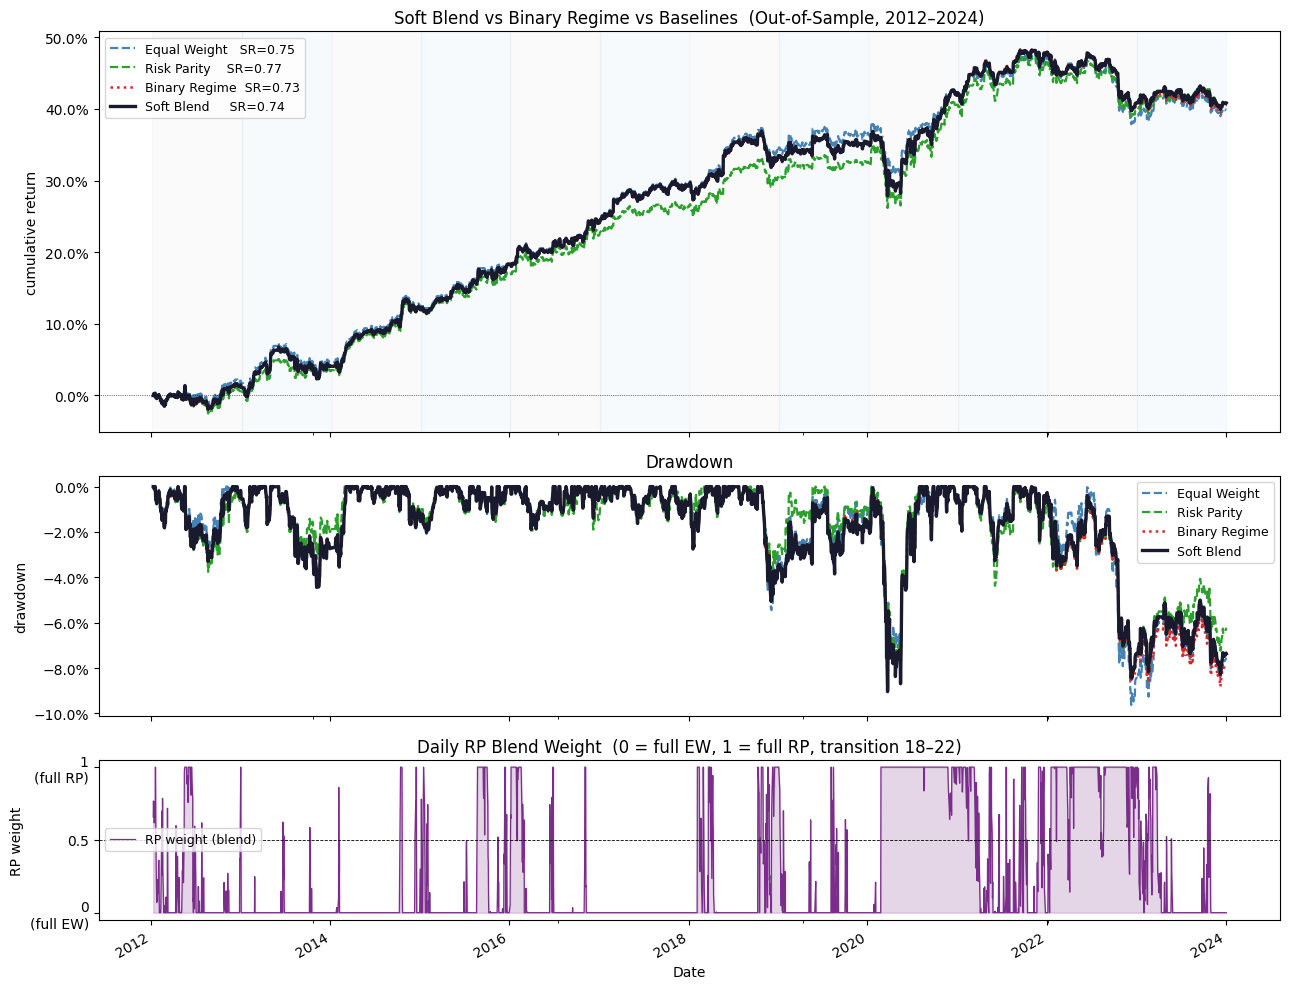

In [12]:
ew_eq     = ew_daily.cumsum()
rp_eq     = rp_daily.cumsum()
reg_eq    = regime_daily.cumsum()
blend_eq  = blend_daily.cumsum()

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True,
                         gridspec_kw={'height_ratios': [2.5, 1.5, 1]})

# --- Panel 1: Equity curves ---
for i, w_ref in enumerate(best_wfs[PROFITABLE_PAIRS[0]]['windows']):
    axes[0].axvspan(w_ref['test_start'], w_ref['test_end'],
                    alpha=0.04, color='grey' if i % 2 == 0 else 'steelblue')

ew_eq.plot(ax=axes[0],   color='steelblue',  linewidth=1.6, linestyle='--',
           label=f'Equal Weight   SR={ew_stats["sharpe_ratio"]:.2f}')
rp_eq.plot(ax=axes[0],   color='#2ca02c',    linewidth=1.6, linestyle='--',
           label=f'Risk Parity    SR={rp_stats["sharpe_ratio"]:.2f}')
reg_eq.plot(ax=axes[0],  color='#d62728',    linewidth=1.8, linestyle=':',
            label=f'Binary Regime  SR={regime_stats["sharpe_ratio"]:.2f}')
blend_eq.plot(ax=axes[0], color='#1a1a2e',   linewidth=2.4,
              label=f'Soft Blend     SR={blend_stats["sharpe_ratio"]:.2f}')
axes[0].axhline(0, color='k', linewidth=0.5, linestyle=':')
axes[0].set_title('Soft Blend vs Binary Regime vs Baselines  (Out-of-Sample, 2012–2024)')
axes[0].set_ylabel('cumulative return')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
axes[0].legend(fontsize=9)

# --- Panel 2: Drawdown ---
for eq, color, ls, lw, label in [
    (ew_eq,    'steelblue', '--', 1.6, 'Equal Weight'),
    (rp_eq,    '#2ca02c',   '--', 1.6, 'Risk Parity'),
    (reg_eq,   '#d62728',   ':',  1.8, 'Binary Regime'),
    (blend_eq, '#1a1a2e',   '-',  2.4, 'Soft Blend'),
]:
    dd = eq - eq.cummax()
    dd.plot(ax=axes[1], color=color, linewidth=lw, linestyle=ls, label=label)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('drawdown')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
axes[1].legend(fontsize=9)

# --- Panel 3: Blend weight over time ---
w_series = pd.Series(
    blend_weight(vix_lag.values, low=VIX_LOW, high=VIX_HIGH),
    index=ew_daily.index,
)
w_series.plot(ax=axes[2], color='#7b2d8b', linewidth=0.9, label='RP weight (blend)')
axes[2].axhline(0.5, color='k', linewidth=0.6, linestyle='--')
axes[2].fill_between(w_series.index, 0, w_series.values, alpha=0.2, color='#7b2d8b')
axes[2].set_ylabel('RP weight')
axes[2].set_ylim(-0.05, 1.05)
axes[2].set_yticks([0, 0.5, 1])
axes[2].set_yticklabels(['0\n(full EW)', '0.5', '1\n(full RP)'])
axes[2].set_title(f'Daily RP Blend Weight  (0 = full EW, 1 = full RP, transition {VIX_LOW:.0f}–{VIX_HIGH:.0f})')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
blend_ann = blend_daily.groupby(blend_daily.index.year).sum()
reg_ann   = regime_daily.groupby(regime_daily.index.year).sum()

print(f"{'Year':<6} {'VIX>20':>7} {'EW':>9} {'RP':>9} {'Binary':>9} {'Soft':>9} {'Best':>8}")
print("-" * 62)
for year in ew_ann.index:
    ew  = ew_ann[year]
    rp  = rp_ann.get(year, 0.0)
    reg = reg_ann.get(year, 0.0)
    bld = blend_ann.get(year, 0.0)
    hv  = hv_pct.get(year, 0.0)
    best_val = max(ew, rp, reg, bld)
    winner = {ew: 'EW', rp: 'RP', reg: 'Binary', bld: 'Soft'}[best_val]
    print(f"{year:<6} {hv:>6.0%}  {ew:>8.1%}  {rp:>8.1%}  {reg:>8.1%}  {bld:>8.1%}  {winner:>8}")

soft_wins = sum(1 for y in ew_ann.index if blend_ann.get(y,0) >= max(ew_ann[y], rp_ann.get(y,0), reg_ann.get(y,0)))
print(f"\nSoft blend wins (or ties best): {soft_wins}/{len(ew_ann)} years")

Year    VIX>20        EW        RP    Binary      Soft     Best
--------------------------------------------------------------
2012      17%      2.1%      0.9%      1.4%      1.5%        EW
2013       1%      2.6%      2.6%      2.6%      2.6%      Soft
2014       4%      7.9%      8.4%      8.1%      8.1%        RP
2015      17%      5.9%      5.4%      6.2%      6.2%    Binary
2016      17%      5.8%      5.0%      5.6%      5.7%        EW
2017       0%      5.2%      3.9%      5.2%      5.2%      Soft
2018      23%      4.8%      4.1%      3.9%      4.0%        EW
2019       6%      2.3%      2.1%      2.1%      2.0%        EW
2020      86%      5.9%      8.1%      7.1%      7.1%        RP
2021      36%      4.8%      6.0%      5.7%      5.6%        RP
2022      91%     -8.2%     -6.8%     -7.3%     -7.0%        RP
2023      17%      0.8%      1.1%     -0.3%     -0.1%        RP
2024       0%      0.1%      0.1%      0.1%      0.1%      Soft

Soft blend wins (or ties best): 3/13 yea

> **Observations: Soft Blend vs Binary Regime**
>
> The soft blend is marginally better than binary regime switching, but does not improve on pure risk parity. The continuous weight reduces the number of abrupt full-portfolio flips, but the VIX signal itself is not informative enough for this portfolio to justify any form of regime switching.
>
> The bottom panel of the chart makes this visible: the RP weight oscillates continuously throughout the test period, spending significant time in the transition zone. This is the correct behavior for a soft-threshold blender; it is responding to VIX as intended. The problem is not the switching mechanism; it is that the underlying signal is redundant with what risk parity is already doing structurally.
>
> **The honest finding:** For a market-neutral pairs strategy weighted by risk parity, VIX-based regime conditioning adds no material value. Risk parity's inverse-volatility weighting already downweights the most volatile pairs when markets are stressed, which is the same thing the VIX signal is trying to achieve, but implemented at the pair level rather than the portfolio level. Adding an external regime signal on top of that is solving a problem that has already been solved.
>
> **What this notebook does establish** is the `blend_weight()` architecture: a single function that maps a signal to a portfolio weight, with a clean interface for substitution. If a genuinely informative signal were available, one that predicted something risk parity does not already capture, plugging it in requires no changes to the portfolio construction. The VIX happened not to be that signal for this portfolio.